Request data from GEE

In [20]:
# --------------------------
# SET UP
# --------------------------
import os
os.environ.setdefault("RUN_DEMO", "ON")
import src.config as c
import src.load_data as ld
import src.google_ee as gee
import src.preprocessing_general as pps
import geopandas as gpd
from pathlib import Path
import pandas as pd
import utils as u
from datetime import datetime


# --------------------------
# VARIABLES
# --------------------------
YEAR_FILTER     = [2018,2019]
CRS             = "EPSG: 4326"          # Set Coordinate Reference System (CRS) so it is uniform across all data inputs
SATELITE_IMAGES = "COPERNICUS/S2_SR_HARMONIZED"   
DATA_DIR        = os.environ.get("DATA_DIR")
RUN_ID          = f"{datetime.strftime(datetime.now(), '%Y%m%d%H%M')}_RUNNING_DEMO_{os.environ.get('RUN_DEMO')}"
RANDOM_SEED     = 42

# --------------------------
# LOAD DATA
# --------------------------
#region
# --------------------------
# VIIRS DATA
# --------------------------

viirs_dict = ld.viirs_load_pipeline(dir_name   = 'VIIRS',
                                    crs        = CRS,
                                    date_range = YEAR_FILTER)
df_viirs = viirs_dict.get('df_viirs')
print(f"{'='*80}")
print(f"🔥 VIIRS Data")
print(f"\tVIIRS data report\n\t\t{viirs_dict.get('data_report')}")
print(f"\tData Type: {type(df_viirs)}")
print(f"\t📅 Date Range: {df_viirs['date'].min()} to {df_viirs['date'].max()}")
print(df_viirs.head())

# --------------------------
# UK GRID 
# --------------------------
df_uk_grid = ld.load_uk_grid(file_name ='ukcp18-uk-land-12km.shp', 
                             crs       = CRS)
print(f"{'='*80}")
print(f"UK Grid")
print(f"Columns: \n\t{df_uk_grid.columns}")
print(f"Shape: \n\t{df_uk_grid.shape}")
print(df_uk_grid.head())

# Grids by Day
print(f"{'='*80}")
print(f"🇬🇧 UK Grid Daily")
df_daily_grid = ld.uk_grid_data_pipeline(df_uk_grid, df_viirs)
print(f"Daily UK Grid Columns: \n\t{df_daily_grid.columns}")
print(type(df_daily_grid['date'][0]))
print(f"Shape: \n\t{df_daily_grid.shape}")
print(df_daily_grid.head())

# -------------------------
# GOOGLE EE SENTINEL-2
# -------------------------
# print(f"{'='*80}")
# print(f"🛰️ GOOGLE EE SENTINEL-2")  
# # Get stored files 
# sentinel_path  = Path(DATA_DIR)/"sentinel2"
# df_sentinel = ld.sentinel_load_pipeline(sentinel_path,
#                                         df_daily_grid[df_daily_grid['date'] < '2019-01-31'],
#                                         SATELITE_IMAGES)
# print(df_sentinel.head())

# -------------------------
# FIRE WEATHER INDEX 
# -------------------------
print(f"{'='*80}")
print(f"🌡️ FIRE WEATHER INDEX")  
fwi_path    = Path(DATA_DIR)/"FWI"
df_fwi = ld.fwi_load_pipeline(fwi_path         = fwi_path, 
                              df_uk_daily_grid = df_daily_grid,
                              df_uk_grid       = df_uk_grid,
                              crs              = CRS,
                              grb_name         = 'Forest fire weather index (as defined by the Canadian Forest Service)')
print(type(df_fwi['date'].max()))
print(df_fwi.shape)
print(df_fwi.head())

#endregion





🔥 VIIRS Data
	VIIRS data report
		{'total_rows_snpp': 17360, 'total_rows_noaa': 15880}
	Data Type: <class 'geopandas.geodataframe.GeoDataFrame'>
	📅 Date Range: 2018-01-01 00:00:00 to 2019-12-31 00:00:00
    latitude  longitude  bright_ti4  scan  track       date  acq_time  \
4   53.58905   -0.60790      295.95  0.65   0.73 2018-01-01       348   
32  53.78033   -0.59153      297.74  0.39   0.59 2018-01-04       111   
35  53.39441   -1.38954      301.80  0.65   0.73 2018-01-05        52   
37  57.58453   -1.83752      304.72  0.39   0.36 2018-01-05       232   
43  51.35634   -0.47676      325.36  0.46   0.39 2018-01-05      1222   

   satellite instrument confidence  version  bright_ti5   frp daynight  type  \
4          N      VIIRS          n        2      273.02  0.85        N     0   
32         N      VIIRS          n        2      265.33  0.74        N     0   
35         N      VIIRS          n        2      272.14  1.54        N     0   
37         N      VIIRS          n    

🏗️ PRE PROCESSING
	✅ Succesfully saved outputs/202602280940_RUNNING_DEMO_ON/202602280940_RUNNING_DEMO_ON_LOAD_METADATA.json
	ℹ️  Removed 730 rows with grid_id == 1
	✅ Succesfully saved outputs/202602280940_RUNNING_DEMO_ON/202602280940_RUNNING_DEMO_ON_PREPROCESSING_METADATA.json
🔬 SAMPLING FIRE/NOFIRE


/Users/enmanuelmoreno/Documents/Universities/Birkbeck/MSc Data Science/MSc DS Current/MSc Project/MScProjectWildFirePredict/src/preprocessing_general.py:512: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(months, rotation=45)


	✅ Succesfully saved outputs/202602280940_RUNNING_DEMO_ON/202602280940_RUNNING_DEMO_ON_Monthly Observation Counts (Fire vs No Fire) [Predicted Values].pdf
	✅ Succesfully saved outputs/202602280940_RUNNING_DEMO_ON/202602280940_RUNNING_DEMO_ON_HeatMap of Sampled Grids [Predicted Values][2018-01-02 2019-12-31].pdf
Proportion of Sampled values:
fire_lbl_dv
False    0.748759
True     0.251241
Name: proportion, dtype: Float64


,date_dv,grid_id_dv,fire_lbl_dv,bridge_composite_key_dv,grid_id,x_coord,y_coord,geometry,date,viirs_n,frp_max,frp_mean,fire_lbl,fwi_max,fwi_mean,composite_key
0,2018-04-06,2,True,220180405,2.0,150000.0,30000.0,"POLYGON ((-5.57824 50.0609, -5.58629 50.16861,...",2018-04-05,0.0,0.0,0.0,False,0.525391,0.525391,220180405
1,2019-05-30,3,True,320190529,3.0,162000.0,30000.0,"POLYGON ((-5.41089 50.06595, -5.41857 50.17368...",2019-05-29,0.0,0.0,0.0,False,6.867285,6.867285,320190529
2,2019-06-26,3,True,320190625,3.0,162000.0,30000.0,"POLYGON ((-5.41089 50.06595, -5.41857 50.17368...",2019-06-25,0.0,0.0,0.0,False,0.587500,0.587500,320190625
3,2018-05-06,4,True,420180505,4.0,174000.0,30000.0,"POLYGON ((-5.2435 50.07075, -5.2508 50.1785, -...",2018-05-05,0.0,0.0,0.0,False,1.492578,1.492578,420180505
4,2018-10-10,4,True,420181009,4.0,174000.0,30000.0,"POLYGON ((-5.2435 50.07075, -5.2508 50.1785, -...",2018-10-09,0.0,0.0,0.0,False,5.946680,5.946680,420181009


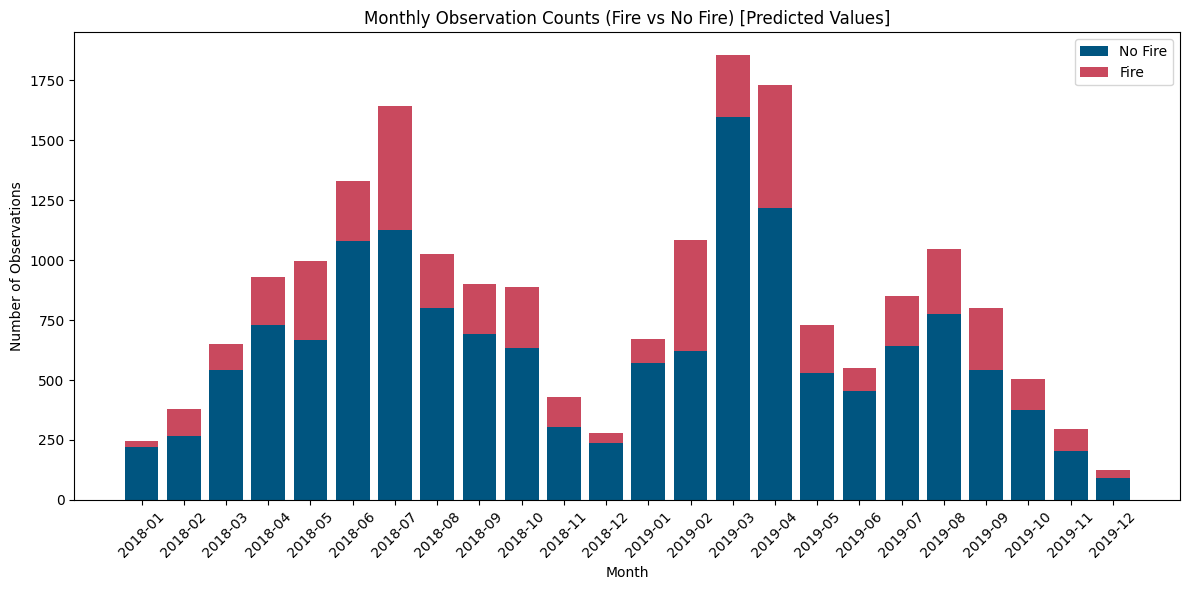

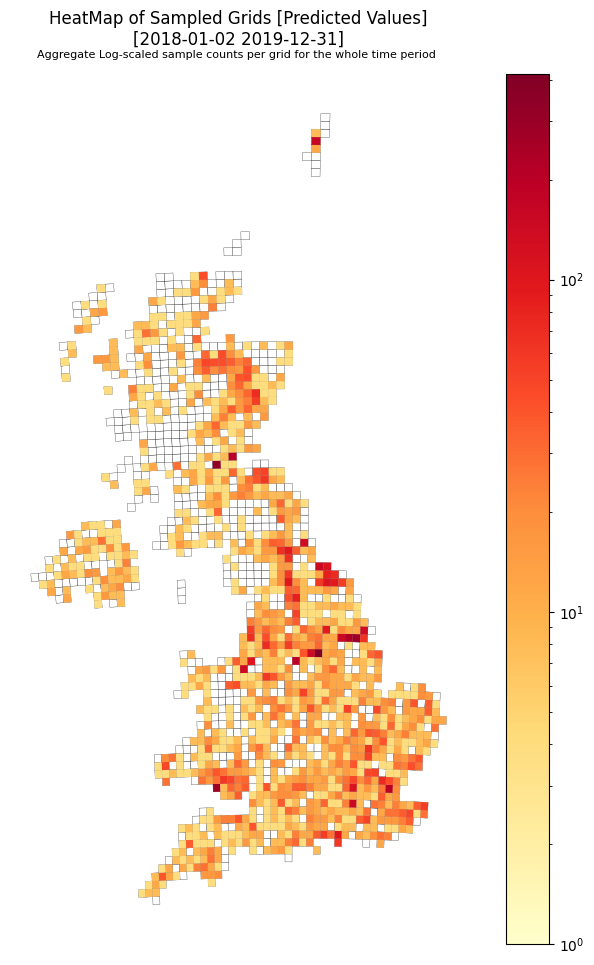

In [27]:
# --------------------------
# PRE PROCESSING
# --------------------------
#region
print(f"{'='*80}")
print(f"🏗️ PRE PROCESSING")  

dfs_loaded = {'df_viirs'     : df_viirs,
              'df_uk_grid'   : df_uk_grid,
              'df_daily_grid': df_daily_grid,
              'df_fwi'       : df_fwi}
df_model_pre = pps.preprocessing_pipeline(dfs_loaded, RUN_ID)
#endregion

# --------------------------
# SAMPLING FIRE/NOFIRE
# --------------------------
#region
print(f"{'='*80}")
print(f"🔬 SAMPLING FIRE/NOFIRE")  
df_sampled = pps.sampling_pipeline(df_preprocessed              = df_model_pre, 
                                   nofire_proximity_window_days = 30, 
                                   nofire_total_samples         = 3,
                                   random_seed                  = RANDOM_SEED)
pps.sampling_reporting_pipeline(df_plot         = df_sampled, 
                                df_uk_grid      = df_uk_grid, 
                                uk_sp_file_name = 'ukcp18-uk-land-12km.shp',
                                crs             = CRS, 
                                run_id          = RUN_ID)
df_sampled.head()
#endregion

In [28]:
print(df_sampled['date'].min())
print(df_sampled['date'].max())
print(df_sampled.shape)



2018-01-01 00:00:00
2019-12-30 00:00:00
(19941, 16)


In [22]:
sentinel_test = df_sampled.iloc[10:15]
sentinel_test_gpd = gpd.GeoDataFrame(sentinel_test, geometry = 'geometry')
sentinel_test_gpd.set_crs(CRS, inplace=True)

,date_dv,grid_id_dv,fire_lbl_dv,bridge_composite_key_dv,grid_id,x_coord,y_coord,geometry,date,viirs_n,frp_max,frp_mean,fire_lbl,fwi_max,fwi_mean,composite_key
10,2018-04-12,8,True,820180411,8.0,270000.0,42000.0,"POLYGON ((-3.90727 50.20835, -3.91158 50.31621...",2018-04-11,0.0,0.0,0.0,False,0.006055,0.006055,820180411
11,2018-07-12,9,True,920180711,9.0,174000.0,54000.0,"POLYGON ((-5.25814 50.28625, -5.26553 50.39399...",2018-07-11,0.0,0.0,0.0,False,3.684570,3.684570,920180711
12,2018-09-27,9,True,920180926,9.0,174000.0,54000.0,"POLYGON ((-5.25814 50.28625, -5.26553 50.39399...",2018-09-26,0.0,0.0,0.0,False,2.109375,2.109375,920180926
13,2018-05-06,10,True,1020180505,10.0,186000.0,54000.0,"POLYGON ((-5.08996 50.29084, -5.09696 50.39861...",2018-05-05,0.0,0.0,0.0,False,0.846875,0.846875,1020180505
14,2018-05-19,10,True,1020180518,10.0,186000.0,54000.0,"POLYGON ((-5.08996 50.29084, -5.09696 50.39861...",2018-05-18,0.0,0.0,0.0,False,1.966992,1.966992,1020180518


Sentinel Download Pilot Test

In [49]:
df_sampled[df_sampled['date'] == '2018-04-06'].shape

(24, 16)

In [50]:
import ee
import numpy as np
import requests
import io
import tifffile
import pandas as pd
from skimage.transform import resize

try:
    ee.Initialize(project = "ee-enmanuelmorego")
except:
    ee.Authenticate()
    ee.Initialize(project = "ee-enmanuelmorego")

print(f"CRS Object: {CRS.replace(' ','')}")
def pilot_test(df, num_samples = 10):
    pilot_df   = df.sample(num_samples, random_state = 42)
    image_list = []
    label_list = []
    composite_key_list = []

    print(f"🚀 Starting Pilot Test for {num_samples} samples...")
    print(pilot_df.shape)

    for row in pilot_df.itertuples():
        i = row.Index
        try:
            # Extract key variables 
            geom     = ee.Geometry(row.geometry.__geo_interface__)
            date_str = row.date

            # Get satelite image object
            img = (ee.ImageCollection(SATELITE_IMAGES)
                .filterBounds(geom)
                .filterDate(ee.Date(date_str).advance(-5, 'day'),
                            ee.Date(date_str).advance(1, 'day'))
                            .select(["B2","B3","B4","B8"])
                            .median()
                            .clip(geom))
            # Download image to RAM rather than to disk 
            url = img.getDownloadURL({'scale': 80,
                                    'crs': CRS.replace(" ",""),
                                    'region': geom,
                                    'format': 'GEO_TIFF'})
            response = requests.get(url)
            with io.BytesIO(response.content) as f:
                # REad all 4 bands
                data = tifffile.imread(f)
            # Clean and standarise
            data = np.nan_to_num(data, nan=0.0)
            # Fix axes: we want (Height, Width, 4)
            if data.shape[0] == 4: # If (Bands, H, W)
                data = np.moveaxis(data, 0, -1)
            elif data.shape[1] == 4: # If (H, Bands, W)
                data = np.moveaxis(data, 1, -1)
            # Resize to a consistent square/size for CNN 128 x 128
            data_resized = resize(data, (128,128), anti_aliasing=True).astype('float32')
            image_list.append(data_resized)
            label_list.append(row.fire_lbl)
            composite_key_list.append(row.composite_key)
            print(f"✅ Downloaded & Resized {i+1}: {data_resized.shape}")
        except Exception as e:
            print(f"❌ Error on row {i}: {e}")

           # 4. Save as a Compressed Shard
    X = np.array(image_list)
    y = np.array(label_list)
    ids = np.array(composite_key_list)
    np.savez_compressed("pilot_shard_1.npz", x=X, y=y, ids=ids)
    print(f"\n🎉 Success! Saved 'pilot_shard_1.npz' ({X.nbytes / 1e6:.2f}")

# Run pilot
pilot_test(df_sampled)


CRS Object: EPSG:4326
🚀 Starting Pilot Test for 10 samples...
(10, 16)
✅ Downloaded & Resized 14191: (128, 128, 4)
✅ Downloaded & Resized 16860: (128, 128, 4)
✅ Downloaded & Resized 14490: (128, 128, 4)
✅ Downloaded & Resized 13947: (128, 128, 4)
✅ Downloaded & Resized 3271: (128, 128, 4)
✅ Downloaded & Resized 16372: (128, 128, 4)
✅ Downloaded & Resized 5108: (128, 128, 4)
✅ Downloaded & Resized 8842: (128, 128, 4)
✅ Downloaded & Resized 11217: (128, 128, 4)
✅ Downloaded & Resized 16209: (128, 128, 4)

🎉 Success! Saved 'pilot_shard_1.npz' (2.62


The npz file is like a folder compressed into a single file. it contains :
x float32 the actual pixels for each of the bands
y bool whether is fire or no fire (kept for validation consistenct and deasy debugging)
ids int64 the composite id of date+grid id to map to the rest of the data 

In [54]:
# Load the shard back in
test_data = np.load("pilot_shard_1.npz")
X_test = test_data['x']
y_test = test_data['y']

print(f"files {test_data.files}")
print(f"Shape of X: {X_test.shape}") # Should be (10, H, W, 4)
print(f"Labels: {y_test}")
print(f"Global Max Value: {np.max(X_test)}") 
print()
print(test_data['ids'])
print(test_data['x'])
print(test_data['y'])



files ['x', 'y', 'ids']
Shape of X: (10, 128, 128, 4)
Labels: [False False False False False False False False False False]
Global Max Value: 18313.23828125

['115720191008' '161120180602' '119220190321' '113220181220'
 '129420190711' '150220190407' '1520180413' '32920181021' '78520180630'
 '149520180413']
[[[[10865.682   10383.499    9814.035    9921.275  ]
   [10549.25     9998.217    9351.539    9651.913  ]
   [10069.025    9531.326    8999.626    9239.154  ]
   ...
   [12189.212   11910.049   11324.297   11710.166  ]
   [12113.277   11865.047   11304.059   11661.028  ]
   [12047.212   11744.382   11173.845   11592.633  ]]

  [[10281.603    9819.212    9290.622    9445.126  ]
   [ 9938.451    9447.994    8836.065    9178.481  ]
   [10000.207    9546.785    8894.582    9213.828  ]
   ...
   [12396.408   12192.498   11608.271   11958.137  ]
   [12361.98    12138.397   11537.441   11913.385  ]
   [12206.049   11955.312   11412.758   11753.707  ]]

  [[ 9804.367    9421.873    8785.29  


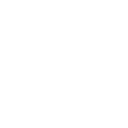

In [57]:
import folium
import numpy as np

# 1. Prepare the Image for Display
# Sentinel-2 RGB: Bands 2, 1, 0 (B4, B3, B2)
img_rgb = X_test[0][:, :, [2, 1, 0]]

# Scale 0-18000 down to 0-1 for folium
# We divide by 4000 to 'stretch' it so it's not a dark square
img_norm = np.clip(img_rgb / 4000, 0, 1)

# 2. Get the Bounds from your original GeoDataFrame
# We need the [min_lat, min_lon], [max_lat, max_lon]
first_row = df_sampled.sample(10, random_state=42).iloc[0]
bounds = first_row.geometry.bounds # (minx, miny, maxx, maxy)
# Folium expects [[min_lat, min_lon], [max_lat, max_lon]]
sw = [bounds[1], bounds[0]]
ne = [bounds[3], bounds[2]]
img_bounds = [sw, ne]

# 3. Create the Map
m = folium.Map(location=[(sw[0] + ne[0])/2, (sw[1] + ne[1])/2], zoom_start=12)

# Add the NumPy array as an Overlay
folium.raster_layers.ImageOverlay(
    image=img_norm,
    bounds=img_bounds,
    opacity=0.7,
    name="Sentinel Verification"
).add_to(m)

# Add the Grid Boundary to see the fit
folium.GeoJson(first_row.geometry.__geo_interface__).add_to(m)

m
